<a href="https://colab.research.google.com/github/isAmirKhashimov/scikit-learn-labs/blob/stud%2Fkhashimov%2Flab1/stud/khashimov/lab1/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget -O lab1-10.csv "https://raw.githubusercontent.com/isAmirKhashimov/scikit-learn-labs/stud/khashimov/lab1/tasks/lab1/dataset/lab1-10.csv"


--2026-09-23 14:05:21--  https://raw.githubusercontent.com/isAmirKhashimov/scikit-learn-labs/stud/khashimov/lab1/tasks/lab1/dataset/lab1-10.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10008 (9.8K) [text/plain]
Saving to: ‘lab1-10.csv’

lab1-10.csv         100%[===================>]   9.77K  --.-KB/s    in 0s      

2026-09-23 14:05:21 (87.4 MB/s) - ‘lab1-10.csv’ saved [10008/10008]



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import csv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
with open("lab1-10.csv", "r") as f:
    data = csv.reader(f)
    dataArr = [i for i in data]
    first = [float(i[0]) for i in dataArr]
    second = [float(i[1]) for i in dataArr]


In [ ]:
len(first)

200

In [ ]:
print(second)

[9.211128412493698, 3.918031850861263, 3.823336170157877, 4.012567982071899, 4.758146837481847, 5.130030080955017, 3.7743219946551285, 2.8623829403397254, 4.167480048531423, 9.688279383328375, 1.3242394654016163, 4.918039594634587, 3.3876341519126574, 2.670725051155477, 4.232444416185217, 6.224152816765026, 3.782125134175864, 1.9103598724457924, 2.1865196862263465, 2.291464302455333, 7.5255559702440085, 3.3868784368992735, 4.087231593774854, 2.5060894541240613, 3.9425419163945343, 0.18858097428950948, 2.716496697599152, 4.26736139508931, 4.189153057054637, 1.6975835752888948, 10.043930661589215, 1.8689221791622685, 2.646141710801109, 1.6765674357927738, 0.48053283571184635, 2.9850158235825752, 0.7126632818720573, 1.5635946677890438, 2.1879319696271926, 0.3139792387116467, 2.7898035435472552, 2.1565257576014853, 8.828145937666646, 1.5769476278123251, 0.11552352653669229, -0.6211847077776769, 3.0041530478823177, 1.6270488158511172, 1.1840043012590167, 0.5591253405163923, 2.59349825635840

In [ ]:
points = sorted(zip(first, second))

first_sorted = [p[0] for p in points]
second_sorted = [p[1] for p in points]

/tmp/ipykernel_2351/2833907042.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


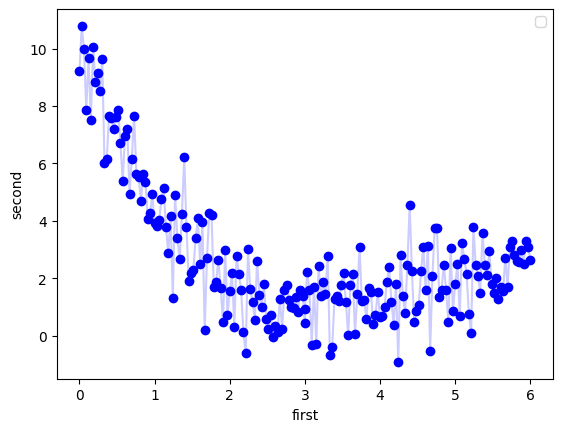

In [149]:
plt.scatter(first, second, color='blue', marker='o')
plt.plot(first_sorted, second_sorted, color='blue', alpha=0.2)

plt.xlabel('first')
plt.ylabel('second')
plt.legend()
plt.Normalize()

plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(first, second, test_size=0.4, random_state=923)

In [ ]:
print(len(x_train))
print(len(x_test))
print(len(y_train))
print(len(y_test))

120
80
120
80


## Гипотезы
Т.к. поведение напоминает параболу, то хотел бы проверить линейную регрессию с кривыми второго и третьего порядка

In [ ]:
def get_polinomial_model(x, degree):
  x = np.array(x).reshape(-1, 1)
  poly = PolynomialFeatures(degree=degree, include_bias=False)
  x_poly = poly.fit_transform(x)
  model = LinearRegression()
  return x_poly, poly, model

In [ ]:
x1, poly1, model1 = get_polinomial_model(x_train, 1)
x2, poly2, model2 = get_polinomial_model(x_train, 2)
x3, poly3, model3 = get_polinomial_model(x_train, 3)

In [ ]:
model1.fit(x1, y_train)
model2.fit(x2, y_train)
model3.fit(x3, y_train)

LinearRegression()

Did not launch cell below because launched in function below

In [153]:
def show_prediction_metrics(model, poly):
  x_test_reshaped = np.array(x_test).reshape(-1, 1)
  x_poly = poly.fit_transform(x_test_reshaped)
  y_pred = model.predict(x_poly)
  print("Coefficients: \n", model.coef_)
  print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
  print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

In [154]:
def show_prediction_plot(model, poly):
  x_train_reshaped = np.array(x_train).reshape(-1, 1)
  x_test_reshaped = np.array(x_test).reshape(-1, 1)

  x_line = np.linspace(
   min(x_train_reshaped.min(), x_test_reshaped.min()),
   max(x_train_reshaped.max(), x_test_reshaped.max()),
   500
  ).reshape(-1, 1)

  y_line = model.predict(poly.transform(x_line))

  plt.scatter(x_train_reshaped, y_train, label='Train')
  plt.scatter(x_test_reshaped, y_test, label='Test')
  plt.plot(x_line, y_line, label='Prediction line')

  plt.xlabel('first')
  plt.ylabel('second')
  plt.legend()
  plt.Normalize()

  plt.show()

In [155]:
def show_model_result(model, poly):
  show_prediction_metrics(model, poly)
  show_prediction_plot(model, poly)

Coefficients: 
 [-0.81427317]
Mean squared error: 3.85
Coefficient of determination: 0.33


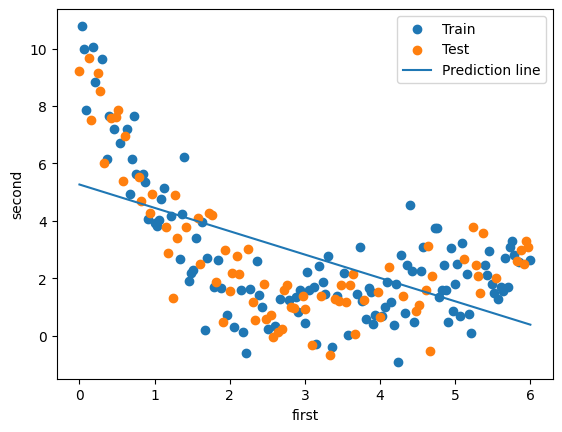

In [156]:
show_model_result(model1, poly1)

Coefficients: 
 [-4.27477942  0.5747874 ]
Mean squared error: 0.96
Coefficient of determination: 0.83


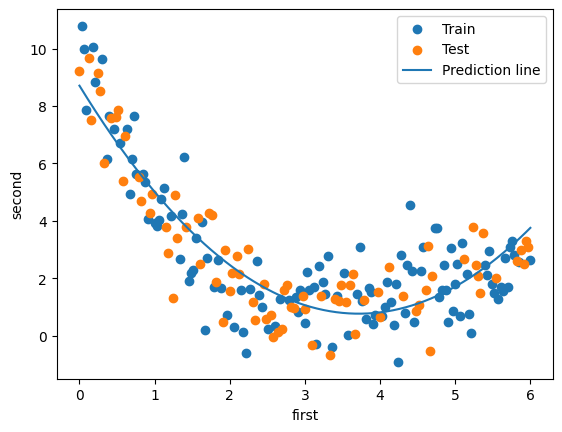

In [157]:
show_model_result(model2, poly2)

Coefficients: 
 [-7.6195896   1.95100559 -0.15201352]
Mean squared error: 0.90
Coefficient of determination: 0.84


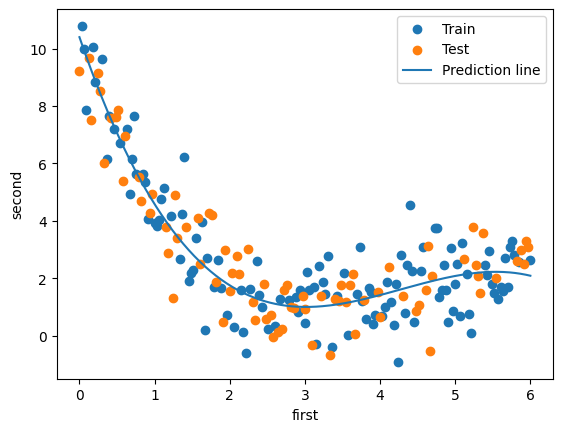

In [158]:
show_model_result(model3, poly3)